# Regressão Linear, Valor de Probabilidade e Métricas

In [204]:
# Importando bibliotecas que serão usadas: 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import csv
import math
import pandas as pd
import shutil

## A $)$ Correlação

### Geração de Gráficos, uso de Regressão Linear e cálculo de Covariância:

Gerar valores similares aos das seguintes figuras, para isso define-se primeiramente uma "semente", que define valores iniciais para geradores de números pseudoaleatórios, com o objetivo de garantir a reprodutibilidade, o que facilita futuras análises de resultado.

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="assets/atv_4/A_func1.png" width="300">
  <img src="assets/atv_4/A_func2.png" width="300">
</div>

In [143]:
np.random.seed(3994)

Função Linregress: 

A função Linregress retorna: 
- o slope(coeficiente angular) 
- o intercept(coeficiente linear) 
- o r-value(coeficiente de correlação Pearson) 
- o p-value(valor de probabilidade) 
- o stderr(erro padrão do coeficiente angular) 
- o intercept_stderr(erro padrão do coeficiente linear)

> Código para as figuras:

In [144]:
# Gráfico 1
x1 = np.random.rand(9) * 2 + 1                              # Cria um vetor com números float aleatórios entre (0,1) e os valores são multiplicados por 2 e soma por 1, é uma distribuição uniforme
y1 = x1 + 0.1                                               # Função y em que cada x da lista é somado com mais 0.1
                                                            # x1 e y1 são para o gráfico 1

media_x1 = sum(x1) / len(x1)                                # Média do X do gráfico 1
media_y1 = sum(y1) / len(y1)                                # Média do Y do gráfico 1
covariancia_1 = sum((x1[i] - media_x1) * (y1[i] - media_y1) for i in range(len(x1)) ) / (len(x1) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado1 = stats.linregress(x1, y1)                       # Nesta parte realiza-se a Regressão Linear para o gráfico 1
pvalue1 = resultado1.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 1

linha_X1 = np.linspace(0, 4, 2)                             # Se cria um vetor com valores que serão usados para desenhar o gráfico
linha_Y1 = resultado1.slope * linha_X1 + resultado1.intercept 
                                                            # Aqui se usa o slope(coeficiente angular) e o intercept(coeficiente linear)

# Gráfico 2

x2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3)
y2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3) 

media_x2 = sum(x2) / len(x2)                                # Média do X no gráfico 2
media_y2 = sum(y2) / len(y2)                                # Média do Y no gráfico 2

covariancia_2 = sum((x2[i] - media_x2) * (y2[i] - media_y2) for i in range(len(x2)) ) / (len(x2) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado2 = stats.linregress(x2, y2)                       # Regressão Linear para o gráfico 2
pvalue2 = resultado2.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 2


linha_X2 = np.linspace(0, 4, 2)
linha_Y2 = resultado2.slope * linha_X2 + resultado2.intercept

> Código dos gráficos:

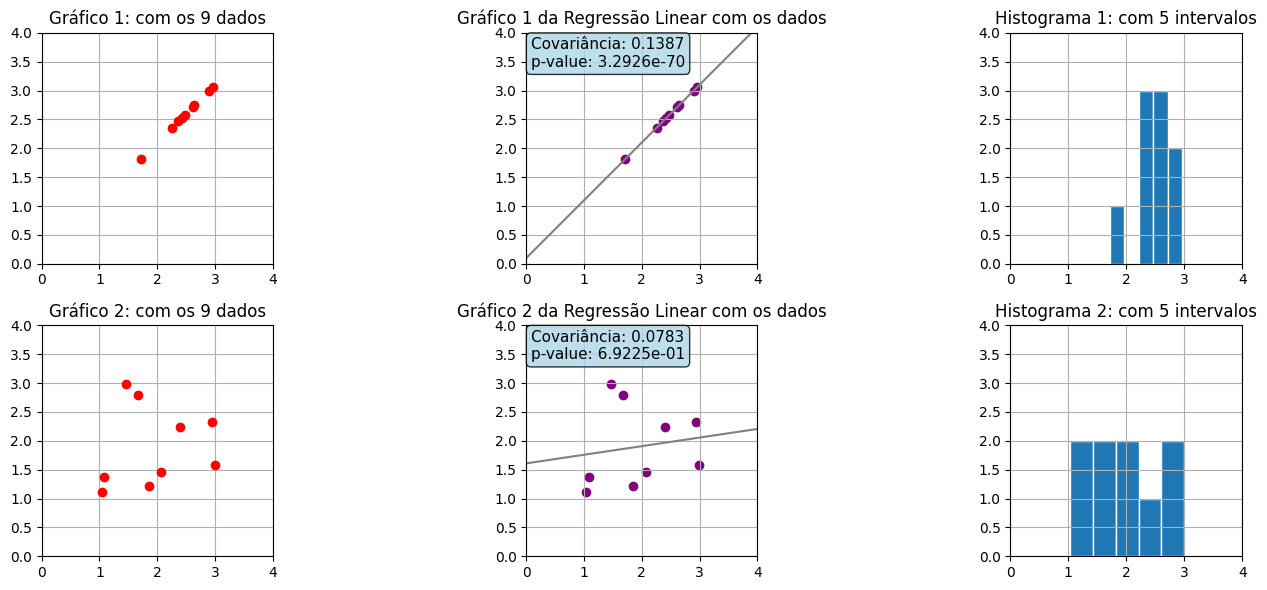

In [145]:
fig, axs= plt.subplots(2, 3, figsize=(16,6))

graph1 = axs[0,0]
graph2 = axs[0,1]
graph3 = axs[0,2]

graph4 = axs[1,0]
graph5 = axs[1,1]
graph6 = axs[1,2]


# Gráfico 1, plotando apenas os 9 pontos
graph1.plot(x1, y1, 'o', color='red')
graph1.set_title('Gráfico 1: com os 9 dados')
graph1.grid(True)
graph1.set_aspect('equal', adjustable='box')
graph1.set_xlim(0,4)
graph1.set_ylim(0,4)

# Gráfico 2, exibindo os 9 valores sob a reta e a reta da Regressão Linear 1
graph2.scatter(x1, y1, color='purple')
graph2.plot(linha_X1, linha_Y1, color='grey')
graph2.set_title('Gráfico 1 da Regressão Linear com os dados')
graph2.grid(True)
graph2.set_aspect('equal', adjustable='box')
graph2.set_xlim(0,4)
graph2.set_ylim(0,4)

info_text1 = (f"Covariância: {covariancia_1:.4f}\n" f"p-value: {pvalue1:.4e}")
graph2.text( 0.02, 0.98, info_text1, transform=graph2.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 3, mostrando o agrupamento dos 9 valores num bin = 5
graph3.hist(x1, bins=5, edgecolor='white')
graph3.set_title('Histograma 1: com 5 intervalos')
graph3.set_xlim(0,4)
graph3.set_ylim(0,4)
graph3.grid(True)
graph3.set_aspect(0.995) 

# Gráfico 4, mostrando a disposição dos dados no segundo caso
graph4.plot(x2, y2, 'o', color='red')
graph4.set_title('Gráfico 2: com os 9 dados')
graph4.grid(True)
graph4.set_aspect('equal', adjustable='box')
graph4.set_xlim(0,4)
graph4.set_ylim(0,4)

# Gráfico 5, exibindo os 9 valores sob a reta e a reta da Regressão Linear 2
graph5.scatter(x2, y2, color='purple')
graph5.plot(linha_X2, linha_Y2, color='grey')
graph5.set_title('Gráfico 2 da Regressão Linear com os dados')
graph5.grid(True)
graph5.set_aspect('equal', adjustable='box')
graph5.set_xlim(0,4)
graph5.set_ylim(0,4)

info_text2 = (f"Covariância: {covariancia_2:.4f}\n" f"p-value: {pvalue2:.4e}")
graph5.text( 0.02, 0.98, info_text2, transform=graph5.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 6, msotrando o agrupamento dos 9 valores num bin = 5 para o segundo caso
graph6.hist(x2, bins=5, edgecolor='white')
graph6.set_title('Histograma 2: com 5 intervalos')
graph6.set_xlim(0,4)
graph6.set_ylim(0,4)
graph6.grid(True)
graph6.set_aspect(0.995) 

plt.tight_layout()
plt.show()

#### Interpretação dos Resultados:

Covariância:
- A covariância em ambos gráficos é positiva, o que significa que a relação linear   
entre as variáveis de ambos os gráficos movem-se na mesma direção.

Valor de Probabilidae:
Dada a hipótese nula $H_0$ = '*Se o slope é zero*'
- Para o gráfico 1:
- Para o gráfico 2:

## B $)$ Estimando um Intervalo de Confiança para a Média

O conjunto de dados amostrais é composto pelas taxas de suicídio (por 100.000 habitantes) observadas ao longo de 30 anos, entre 1985 até 2015. Essa variável permite estimar a média populacional e construir intervalos de confiança.”

Para obter os valores dos intervalos de confiança será necessário consultar a tabela de distribuição de probabilidade abaixo:

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="assets/atv_4/tabela_probabilidade.jpg" width="900" height="900">

</div>

- O valor para o $Z_c$ com a confiança em 95% é obtido da seguinte forma:  
 $0.95 \div 2 = 0.4750$, na tabela este valor corresponde a $1.96$.

- O valor para $Z_c$ com a confiança em 90% é obtido da seguinte forma:  
$0.90 \div 2 = 0.4500$, porém na tabela este valor não existe, mas tem os valores $0.44950$ que dá o valor de $Z_1 = 1.64$  
e o outro é $0.45053$ que dá o valor $Z_2 = 1.65$, entre esses valores se faz uma média que é $Z_m = 1.645$, este será o valor usado.

- O valor para $Z_c$ com confiança em 99% é obtido da seguinte forma:  
$0.99 \div 2 = 0.495$, não existe esse valor na tabela, se recorre a aproximação para encontrar o valor, usando os valores tirados da     tabela, para $0.4949$ o $Z_1 = 2.57$ e para $0.4951$ $Z_2 = 2.58$, se faz a média que resulta em $Z_m = 2.575$, este será o valor usado.  

In [247]:
peso = []                                                                                                                       # Usando uma base de dados de 500 pesos
altura = []                                                                                                                     # Usando uma base de dados de 500 alturas

with open('assets/atv_4/person_index.csv', encoding="utf-8") as arquivo1:
    leitor1 = csv.DictReader(arquivo1)
    for linha in leitor1:
        peso.append(float  (linha["Weight"]) )
        altura.append(float(linha["Height"]) )

amostra_n = len(altura)                                                                                                         # Número N de amostras
media_altura = sum(altura) / len(altura)                                                                                        # Média 
variancia = (sum( ((altura[i] - media_altura)**2) for i in range(len(altura)) )) / (len(altura)-1)                              # Variância amostral
desvio_padrao = math.sqrt(variancia)                                                                                            # Desvio padrão amostral
                                                                                                                         
def intervalo_confianca_c1(Zcritc, desvio, media, tamanho, decision):                                                           # Função para calcula o Intervalo de Confiança: Intervalo de Confiaça Superior e Intervalo de Confiaça Inferior
    margem_erro = Zcritc * (desvio/ math.sqrt(tamanho))
    intervalo_Superior = media + margem_erro
    intervalo_Inferior = media - margem_erro
    if decision == 1:
        print(f"Intervalo de Confiança = ({intervalo_Inferior}, {intervalo_Superior})\nMargem de Erro = {(margem_erro):.3f}\n")
    else:
        return media, intervalo_Inferior, intervalo_Superior, f'{(margem_erro):.3f}'

Dada uma base dados amostrais de tamanho $500$ obtém-se os seguintes valores para as estatísticas:

In [248]:
print(max(altura))

195.0


In [249]:
df = pd.DataFrame({ "Estatísticas": [ "Número de Amostras", "Média das Amostras", "Variância", "Desvio Padrão" ], "Valores": [ amostra_n, media_altura, round(variancia, 3), round(desvio_padrao, 3) ]})
df.index = ["", "", "",""]
df

,Estatísticas,Valores
,Número de Amostras,34.000000
,Média das Amostras,169.852941
,Variância,294.250000
,Desvio Padrão,17.154000


O cálculo dos intervalos de confiança gera os seguintes valores:

In [250]:
# Usando pandas
intervalos = []
intervalos.append(intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0))                 # 90% de confiança
intervalos.append(intervalo_confianca_c1(1.96,  desvio_padrao, media_altura, amostra_n, 0))                 # 95% de confiança
intervalos.append(intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0))                 # 99% de confiança
df = pd.DataFrame( intervalos, columns=["Média", "Limite Inferior", "Limite Superior","Margem de Erro"])
df.index = ["90%", "95%", "99%"]
df

,Média,Limite Inferior,Limite Superior,Margem de Erro
90%,169.852941,165.013614,174.692269,4.839
95%,169.852941,164.086934,175.618948,5.766
99%,169.852941,162.277702,177.428180,7.575


Gráfico dos intervalos de confiança:

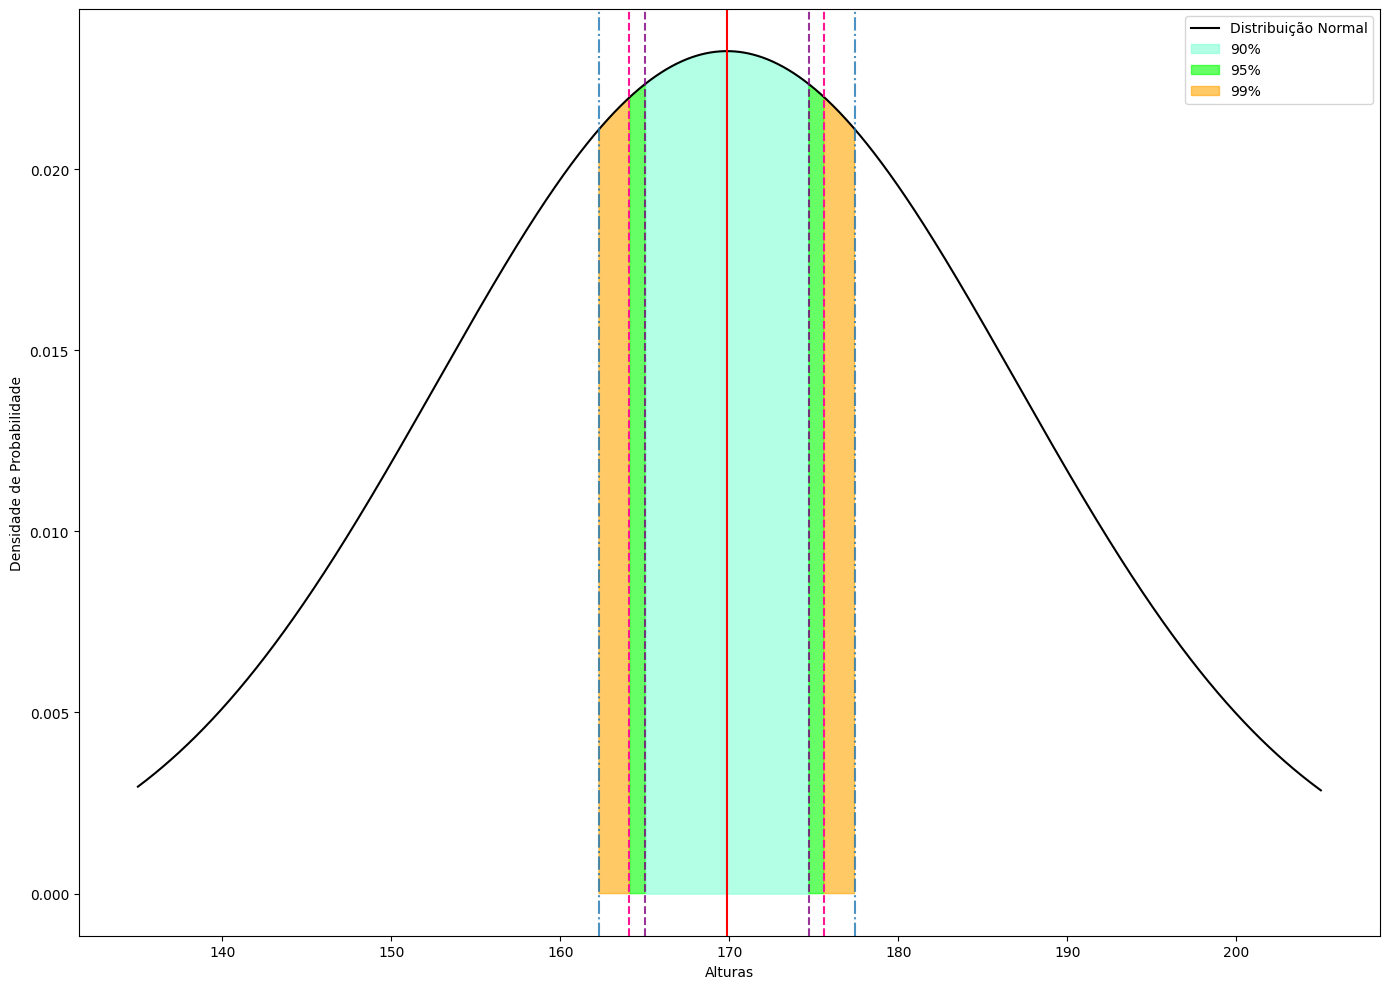

In [307]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import norm


intervalo_inferior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior1 = intervalo_confianca_c1(1.645, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior2 = intervalo_confianca_c1(1.960, desvio_padrao, media_altura, amostra_n, 0)[2]

intervalo_inferior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[1]
intervalo_superior3 = intervalo_confianca_c1(2.575, desvio_padrao, media_altura, amostra_n, 0)[2]


intervalo_x = np.linspace(135, 205, 2000)
p = norm.pdf(intervalo_x, loc=media_altura, scale=desvio_padrao)
plt.figure(figsize=(14, 10))

# Curva total
plt.plot(intervalo_x, p, color='black', label='Distribuição Normal')

# 90%
plt.fill_between( intervalo_x, p, where=(intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1), alpha=0.6, label='90%', color='aquamarine' )

# 95%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)) & ~((intervalo_x >= intervalo_inferior1) & (intervalo_x <= intervalo_superior1)), alpha=0.6, label='95%', color='lime' )

# 99%
plt.fill_between( intervalo_x, p, where=((intervalo_x >= intervalo_inferior3) & (intervalo_x <= intervalo_superior3)) & ~((intervalo_x >= intervalo_inferior2) & (intervalo_x <= intervalo_superior2)), alpha=0.6, label='99%', color='orange' )

# Linhas verticais 
plt.axvline(media_altura, linestyle='-', alpha=1, color='red')

plt.axvline(intervalo_inferior1, linestyle='--', alpha=0.8, color='purple')
plt.axvline(intervalo_superior1, linestyle='--', alpha=0.8, color='purple')

plt.axvline(intervalo_inferior2, linestyle='--', alpha=1, color='deeppink')
plt.axvline(intervalo_superior2, linestyle='--', alpha=1, color='deeppink')

plt.axvline(intervalo_inferior3, linestyle='-.', alpha=0.8)
plt.axvline(intervalo_superior3, linestyle='-.', alpha=0.8)

plt.xlabel('Alturas')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.tight_layout()
plt.show()